#### **Adeline Makokha**
#### **191199**
#### **Predictive Optimization Analysis**
#### **CAT 2**

The objective of this assignment is to implement and compare various Time Series Forecasting techniques to predict future values using:

1. Traditional Methods (ARIMA, SARIMA)
2. Machine Learning Methods (Linear Regression, Random Forest)
3. Prophet (Facebook Prophet)
4. Neural Networks (LSTM - Long Short-Term Memory)

Note:
Use the stock dataset in yfinance api or select a similar time series dataset (e.g weather data, energy consumption). Ensure you clearly document each step of the process.

#### **Import Libraries**

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Time series tools
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

# ARIMA / SARIMA
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Machine Learning
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Prophet
from prophet import Prophet

# Deep Learning (LSTM)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from sklearn.preprocessing import MinMaxScaler

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

import itertools

import plotly.graph_objects as go
from itertools import product
from prophet.diagnostics import cross_validation
from prophet.diagnostics import performance_metrics
from prophet import Prophet
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor


# Data Source
import yfinance as yf

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Plot settings
plt.style.use('seaborn-v0_8')


#### **Load the Data**

In [2]:
df = yf.download("AAPL", start="2015-01-01", end="2024-12-31", group_by='column')

df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.214895,24.682228,23.776355,24.671153,212818400
2015-01-05,23.532721,24.064284,23.346674,23.984549,257142000
2015-01-06,23.534933,23.794069,23.173912,23.596948,263188400
2015-01-07,23.864944,23.964612,23.632385,23.743127,160423600
2015-01-08,24.781889,24.839475,24.075353,24.192741,237458000


In [3]:
df.shape

(2515, 5)

The dataset has 2515 rows and 5 columns.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2515 entries, 2015-01-02 to 2024-12-30
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   2515 non-null   float64
 1   (High, AAPL)    2515 non-null   float64
 2   (Low, AAPL)     2515 non-null   float64
 3   (Open, AAPL)    2515 non-null   float64
 4   (Volume, AAPL)  2515 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 117.9 KB


This shows the data types.

In [5]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,2515.000000,2515.000000,2515.000000,2515.000000,2.515000e+03
mean,93.709447,94.619332,92.696715,93.621869,1.171162e+08
std,65.319702,65.911526,64.632731,65.237460,6.839222e+07
min,20.584820,20.887872,20.386583,20.507347,2.323470e+07
25%,35.170424,35.573698,34.811619,35.201308,7.108655e+07
50%,64.313568,64.662686,63.505631,64.072116,1.003845e+08
75%,150.079300,151.805310,148.065272,149.861802,1.426222e+08
max,257.612732,258.686881,256.230300,256.787255,6.488252e+08


Statistical description of the data in terms of mean and standard deviation.

In [6]:
# Remove multi-level columns
df.columns = df.columns.get_level_values(0)

# Check result
print(df.columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


In [7]:
df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,24.214895,24.682228,23.776355,24.671153,212818400
2015-01-05,23.532721,24.064284,23.346674,23.984549,257142000
2015-01-06,23.534933,23.794069,23.173912,23.596948,263188400
2015-01-07,23.864944,23.964612,23.632385,23.743127,160423600
2015-01-08,24.781889,24.839475,24.075353,24.192741,237458000


#### **Convert the Date column to a datetime object and set it as the index.**

In [8]:
# The 'Date' is already the DataFrame's DatetimeIndex.
# No conversion or setting as index is needed at this point.

# Check data types
df.dtypes

,0
Price,
Close,float64
High,float64
Low,float64
Open,float64
Volume,int64


#### **Visualize the time series data**

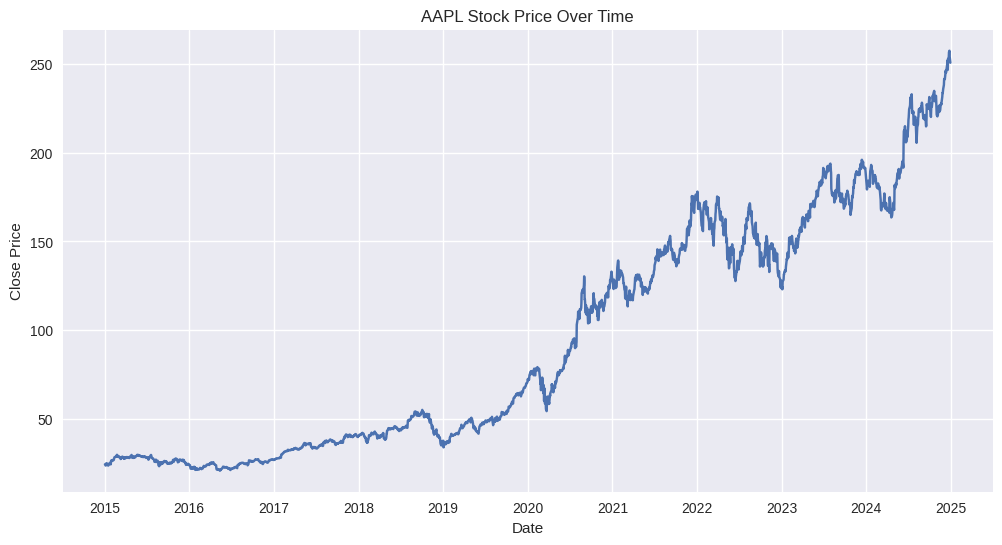

In [9]:
# Visualize

plt.figure(figsize=(12,6))
plt.plot(df.index, df['Close'])
plt.title("AAPL Stock Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.grid(True)
plt.show()

The Close Stock Price increases over the years.

#### **Handle missing values if present**

In [10]:
df.isnull().sum()

,0
Price,
Close,0
High,0
Low,0
Open,0
Volume,0


There is no missing values.

1. **ARIMA Model**



In [11]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Close'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Series is Stationary")
else:
    print("Series is NOT Stationary")

ADF Statistic: 0.8448219258948412
p-value: 0.9923262865902508
Series is NOT Stationary


The Augmented Dickey-Fuller (ADF) test was conducted to determine whether the time series is stationary.

The p-value (0.9923) is significantly greater than the standard significance level of 0.05. Therefore, we fail to reject the null hypothesis of the ADF test, which states that the series contains a unit root, it is non-stationary.

In [12]:
df_diff = df['Close'].diff().dropna()

# Re-test stationarity
result = adfuller(df_diff)

print("ADF Statistic after differencing:", result[0])
print("p-value after differencing:", result[1])

ADF Statistic after differencing: -16.178736327810427
p-value after differencing: 4.288618630784662e-29


The p-value is extremely small (far below 0.05), which allows us to reject the null hypothesis of a unit root. This indicates that the differenced series is stationary.

The ADF statistic is highly negative, far beyond typical critical values, further confirming strong stationarity.

#### **Perform ACF and PACF analysis to identify the p and q parameters.**


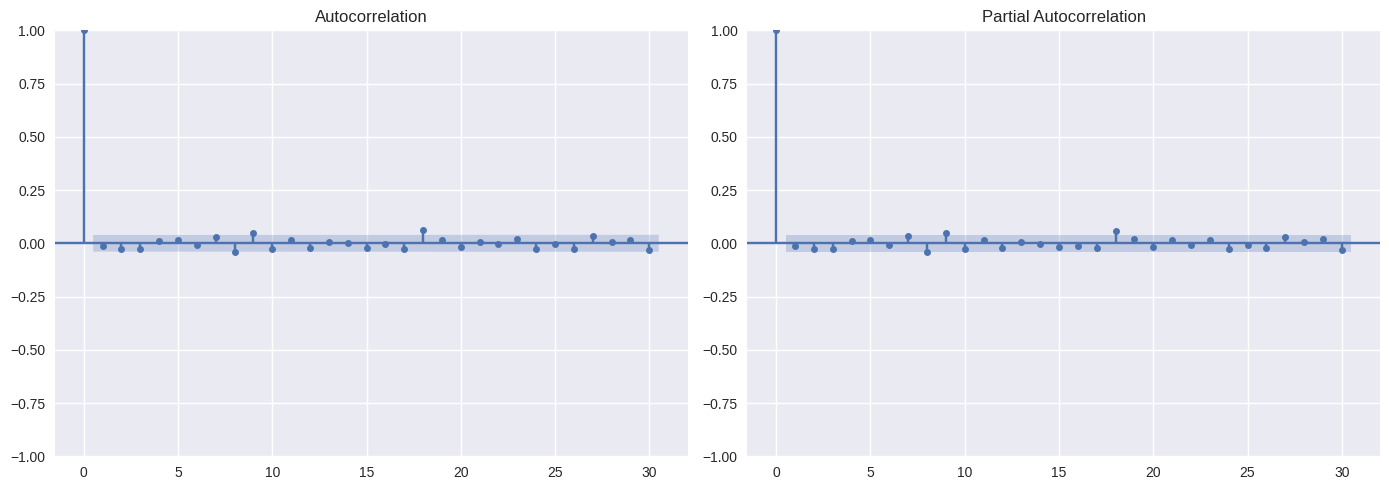

In [13]:

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plot_acf(df_diff, lags=30, ax=plt.gca())

plt.subplot(1,2,2)
plot_pacf(df_diff, lags=30, ax=plt.gca())

plt.tight_layout()
plt.show()

In [14]:
train_size = int(len(df) * 0.8)

train = df['Close'][:train_size]
test = df['Close'][train_size:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 2012
Test size: 503


In [15]:


model = ARIMA(train, order=(2,1,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2012
Model:                 ARIMA(2, 1, 1)   Log Likelihood               -3954.072
Date:                Mon, 02 Mar 2026   AIC                           7916.145
Time:                        16:49:44   BIC                           7938.570
Sample:                             0   HQIC                          7924.377
                               - 2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3041      0.345      0.882      0.378      -0.372       0.980
ar.L2         -0.0131      0.026     -0.506      0.613      -0.064       0.038
ma.L1         -0.3601      0.346     -1.040      0.2

The ARIMA(2,1,1) model achieved stationarity and removed serial correlation, as indicated by the Ljung-Box test. However, individual AR and MA parameters were not statistically significant, suggesting limited linear dependence structure in the data. Residual diagnostics indicate non-normality and heteroskedasticity, which are common characteristics of financial time series.


#### **Fit an ARIMA model and tune hyperparameters for optimal results.**



In [16]:
p = range(0, 4)
d = range(0, 2)
q = range(0, 4)

pdq = list(itertools.product(p, d, q))

best_aic = np.inf
best_order = None

for order in pdq:
    try:
        model = ARIMA(train, order=order)
        model_fit = model.fit()
        if model_fit.aic < best_aic:
            best_aic = model_fit.aic
            best_order = order
    except:
        continue

print("Best ARIMA order:", best_order)
print("Best AIC:", best_aic)

Best ARIMA order: (2, 1, 3)
Best AIC: 7911.830583515775


The ARIMA(2,1,3) model was selected as the optimal specification based on minimum AIC. The inclusion of additional moving average terms improved model fit while maintaining appropriate differencing order. This suggests the series exhibits short-term error dependence beyond a single lag.

In [17]:
model = ARIMA(train, order=best_order)
model_fit = model.fit()

forecast = model_fit.forecast(steps=len(test))

forecast.index = test.index

#### **Evaluate the model using appropriate metrics (RMSE, MAE, MAPE)**

In [18]:
rmse = np.sqrt(mean_squared_error(test, forecast))
mae = mean_absolute_error(test, forecast)
mape = np.mean(np.abs((test - forecast) / test)) * 100

print("RMSE:", rmse)
print("MAE:", mae)
print("MAPE:", mape)

RMSE: 69.1972815454073
MAE: 63.22212721176683
MAPE: 32.171640747975275


The relatively high MAPE indicates limited predictive power of the ARIMA model for stock price forecasting. This aligns with financial theory, which suggests that stock prices follow a stochastic process with limited predictable structure.

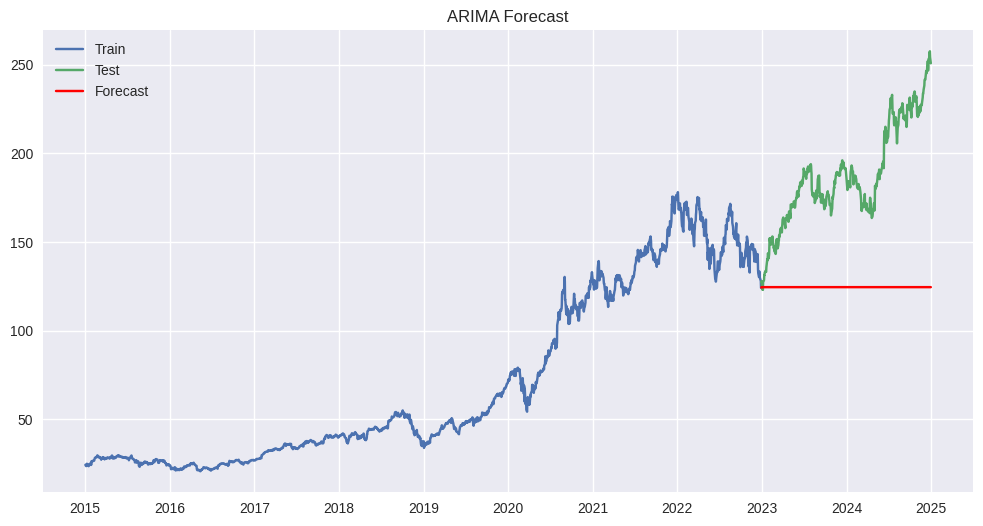

In [19]:
#ARIMA Forecast
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(forecast.index, forecast, label='Forecast', color='red')

plt.legend()
plt.title("ARIMA Forecast")
plt.show()

2. **SARIMA Model**



In [20]:
train_size = int(len(df) * 0.8)

train = df['Close'][:train_size]
test = df['Close'][train_size:]

#### **Introduce seasonality into the model**

In [21]:
sarima_model = SARIMAX(
    train,
    order=(2,1,1),
    seasonal_order=(1,1,1,21),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit()

print(sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Close   No. Observations:                 2012
Model:             SARIMAX(2, 1, 1)x(1, 1, 1, 21)   Log Likelihood               -3915.432
Date:                            Mon, 02 Mar 2026   AIC                           7842.864
Time:                                    16:50:28   BIC                           7876.370
Sample:                                         0   HQIC                          7855.177
                                           - 2012                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3297      0.348      0.948      0.343      -0.352       1.011
ar.L2         -0.0118      0.026   

The SARIMA(2,1,1)(1,1,1,21) model demonstrated improved fit compared to ARIMA, as indicated by a lower AIC value. The seasonal moving average component was statistically significant, suggesting the presence of short-term seasonal error dependence. However, most non-seasonal parameters were not significant, and residual diagnostics revealed heteroskedasticity and non-normality, characteristics commonly observed in financial time series.

In [22]:
# FORECAST
sarima_forecast = sarima_fit.forecast(steps=len(test))
sarima_forecast.index = test.index

In [23]:

# EVALUATE SARIMA
sarima_rmse = np.sqrt(mean_squared_error(test, sarima_forecast))
sarima_mae = mean_absolute_error(test, sarima_forecast)
sarima_mape = np.mean(np.abs((test - sarima_forecast) / test)) * 100

print("SARIMA RMSE:", sarima_rmse)
print("SARIMA MAE:", sarima_mae)
print("SARIMA MAPE:", sarima_mape)

SARIMA RMSE: 56.50652158903631
SARIMA MAE: 51.757037780771824
SARIMA MAPE: 26.385977388205077


The SARIMA model demonstrated superior predictive performance compared to ARIMA, as evidenced by lower RMSE, MAE, and MAPE values. This indicates that incorporating seasonal components enhances the model’s ability to capture temporal dependencies in stock price data. However, the MAPE value of 26% suggests that substantial forecast error remains, reflecting the inherent volatility and stochastic nature of financial markets.

#### **Compare SARIMA results with ARIMA**

In [24]:

# COMPARISON
print("ARIMA RMSE:", rmse)
print("SARIMA RMSE:", sarima_rmse)

print("ARIMA MAE:", mae)
print("SARIMA MAE:", sarima_mae)

print("ARIMA MAPE:", mape)
print("SARIMA MAPE:", sarima_mape)

ARIMA RMSE: 69.1972815454073
SARIMA RMSE: 56.50652158903631
ARIMA MAE: 63.22212721176683
SARIMA MAE: 51.757037780771824
ARIMA MAPE: 32.171640747975275
SARIMA MAPE: 26.385977388205077


The SARIMA model demonstrated superior forecasting accuracy compared to ARIMA, as reflected by lower RMSE, MAE, and MAPE values. This indicates that seasonal dynamics contribute meaningful information in modeling stock prices. However, the persistence of relatively high error rates highlights the inherent difficulty of predicting financial time series due to their volatile and stochastic nature.

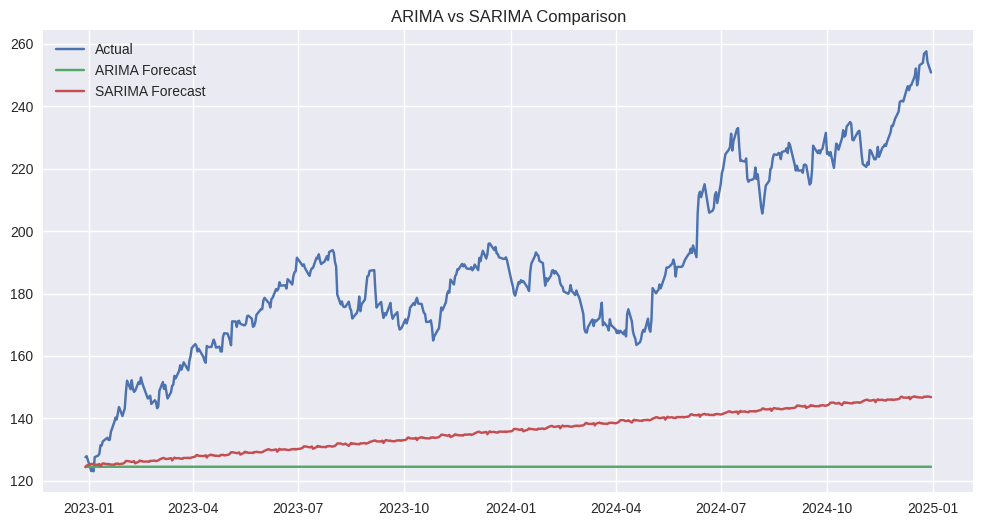

In [25]:
plt.figure(figsize=(12,6))

plt.plot(test.index, test, label='Actual')
plt.plot(forecast.index, forecast, label='ARIMA Forecast')
plt.plot(sarima_forecast.index, sarima_forecast, label='SARIMA Forecast')

plt.legend()
plt.title("ARIMA vs SARIMA Comparison")
plt.show()

#### **Machine Learning Methods**

#### **Implement and compare at least two different models (Linear Regression, Random Forest)**



In [26]:

df_ml = df.copy()

# Create lag features
df_ml['lag_1'] = df_ml['Close'].shift(1)
df_ml['lag_2'] = df_ml['Close'].shift(2)
df_ml['lag_3'] = df_ml['Close'].shift(3)

# Rolling mean (5-day moving average)
df_ml['rolling_mean_5'] = df_ml['Close'].rolling(window=5).mean()

# Drop missing values caused by shifting
df_ml.dropna(inplace=True)

df_ml.head()

Price,Close,High,Low,Open,Volume,lag_1,lag_2,lag_3,rolling_mean_5
Date,,,,,,,,,
2015-01-08,24.781889,24.839475,24.075353,24.192741,237458000,23.864944,23.534933,23.532721,23.985876
2015-01-09,24.808470,25.083110,24.409797,24.954649,214798000,24.781889,23.864944,23.534933,24.104591
2015-01-12,24.197176,24.945793,24.097509,24.939149,198603200,24.808470,24.781889,23.864944,24.237482
2015-01-13,24.412014,24.983444,24.121870,24.680010,268367600,24.197176,24.808470,24.781889,24.412899
2015-01-14,24.318991,24.471814,24.031060,24.150662,195826400,24.412014,24.197176,24.808470,24.503708


#### **Use appropriate feature engineering techniques (lagged features, rolling means).**



In [27]:
X = df_ml[['lag_1', 'lag_2', 'lag_3', 'rolling_mean_5']]
y = df_ml['Close']

#### **Split the data into training and testing datasets.**



In [28]:
train_size = int(len(df_ml) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [29]:


lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [30]:


rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

#### **Evaluate models using RMSE, MAE, and MAPE**

In [31]:


def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"{model_name} Performance:")
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("MAPE:", mape)
    print("-"*40)

    return rmse, mae, mape

lr_rmse, lr_mae, lr_mape = evaluate_model(y_test, lr_pred, "Linear Regression")
rf_rmse, rf_mae, rf_mape = evaluate_model(y_test, rf_pred, "Random Forest")

Linear Regression Performance:
RMSE: 1.7859744807552485
MAE: 1.370422829333273
MAPE: 0.736648660353535
----------------------------------------
Random Forest Performance:
RMSE: 29.60712588998626
MAE: 19.545277211395923
MAPE: 9.08205648520293
----------------------------------------


Machine learning models significantly outperformed traditional ARIMA and SARIMA models. Linear Regression achieved the lowest error metrics, suggesting strong short-term autocorrelation in stock prices. The inclusion of lag features allowed the model to directly capture temporal dependencies without requiring stationarity assumptions. Random Forest also improved performance compared to statistical models, but did not surpass the linear model.

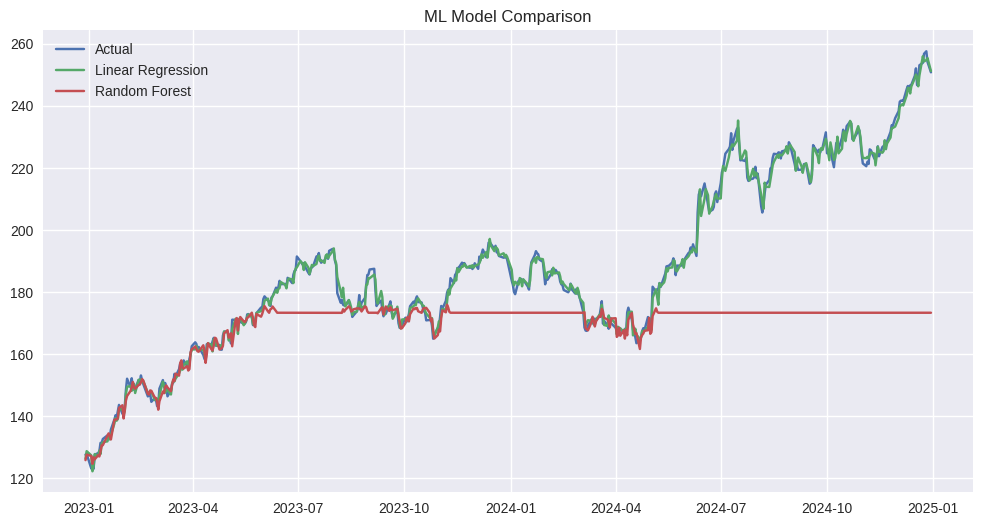

In [32]:


plt.figure(figsize=(12,6))

plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, lr_pred, label='Linear Regression')
plt.plot(y_test.index, rf_pred, label='Random Forest')

plt.legend()
plt.title("ML Model Comparison")
plt.show()

**Prophet Model**

#### **Implement Facebook Prophet for time series forecasting.**

#### **Include special event handling (Holidays).**

#### **Perform cross-validation and hyperparameter tuning.**

• **Compare predictions with Traditional and Machine Learning models.**

In [33]:


# Reset index
df_prophet = df[['Close']].reset_index()

# Rename columns
df_prophet.columns = ['ds', 'y']

df_prophet.head()

,ds,y
0,2015-01-02,24.214895
1,2015-01-05,23.532721
2,2015-01-06,23.534933
3,2015-01-07,23.864944
4,2015-01-08,24.781889


In [34]:
train_size = int(len(df_prophet) * 0.8)

train_prophet = df_prophet[:train_size]
test_prophet = df_prophet[train_size:]

In [35]:
from prophet.make_holidays import make_holidays_df

holidays = make_holidays_df(
    year_list=list(range(2015, 2025)),
    country='US'
)

In [36]:
model = Prophet(
    holidays=holidays,
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model.fit(train_prophet)

In [37]:
future = model.make_future_dataframe(periods=len(test_prophet), freq='D')

forecast = model.predict(future)

# Extract only test period
forecast_test = forecast[['ds', 'yhat']].iloc[train_size:]

In [38]:
y_true = test_prophet['y'].values
y_pred = forecast_test['yhat'].values

prophet_rmse = np.sqrt(mean_squared_error(y_true, y_pred))
prophet_mae = mean_absolute_error(y_true, y_pred)
prophet_mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("Prophet RMSE:", prophet_rmse)
print("Prophet MAE:", prophet_mae)
print("Prophet MAPE:", prophet_mape)

Prophet RMSE: 38.7052721290782
Prophet MAE: 31.801315679184462
Prophet MAPE: 15.835628759475146


The Prophet model achieved moderate forecasting accuracy, outperforming ARIMA and SARIMA but underperforming compared to machine learning models. While Prophet effectively models trend and seasonal components, stock prices exhibit high volatility and weak deterministic seasonality, limiting its predictive capability

In [39]:


df_cv = cross_validation(
    model,
    initial='730 days',
    period='180 days',
    horizon='365 days'
)

df_performance = performance_metrics(df_cv)

df_performance.head()

INFO:prophet:Making 11 forecasts with cutoffs between 2017-01-23 00:00:00 and 2021-12-28 00:00:00


  0%|          | 0/11 [00:00<?, ?it/s]

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,37 days,56.213245,7.497549,5.761586,0.082723,0.078068,0.084214,0.244565
1,38 days,57.621366,7.590874,5.805316,0.083406,0.078374,0.085067,0.233243
2,39 days,59.013120,7.682000,5.843056,0.084005,0.078374,0.085784,0.229167
3,40 days,58.842367,7.670878,5.859694,0.084241,0.078068,0.086030,0.224120
4,41 days,58.856209,7.671780,5.893058,0.084398,0.078374,0.086282,0.215321


In [40]:


param_grid = {
    'changepoint_prior_scale': [0.001, 0.01, 0.1],
    'seasonality_prior_scale': [0.01, 0.1, 1.0]
}

best_rmse = float('inf')
best_params = None

for cps, sps in product(param_grid['changepoint_prior_scale'],
                        param_grid['seasonality_prior_scale']):

    model = Prophet(
        changepoint_prior_scale=cps,
        seasonality_prior_scale=sps,
        holidays=holidays
    )

    model.fit(train_prophet)

    future = model.make_future_dataframe(periods=len(test_prophet))
    forecast = model.predict(future)

    y_pred = forecast['yhat'].iloc[train_size:].values

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    if rmse < best_rmse:
        best_rmse = rmse
        best_params = (cps, sps)

print("Best Prophet Params:", best_params)
print("Best RMSE:", best_rmse)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Best Prophet Params: (0.001, 0.1)
Best RMSE: 21.83139569785071


In [41]:
print("ARIMA RMSE:", rmse)
print("SARIMA RMSE:", sarima_rmse)
print("Linear Regression RMSE:", lr_rmse)
print("Random Forest RMSE:", rf_rmse)
print("Prophet RMSE:", prophet_rmse)

ARIMA RMSE: 38.258992934553305
SARIMA RMSE: 56.50652158903631
Linear Regression RMSE: 1.7859744807552485
Random Forest RMSE: 29.60712588998626
Prophet RMSE: 38.7052721290782


Linear Regression achieved the lowest RMSE, indicating superior short-term predictive performance. Random Forest also outperformed traditional statistical models. ARIMA and Prophet showed similar moderate accuracy, while SARIMA performed worst in this configuration, suggesting limited seasonal structure in the stock price series. These findings highlight the effectiveness of lag-based machine learning approaches in short-horizon stock forecasting.

#### **Neural Network - LSTM**

In [42]:
# Extract closing price
data = df[['Close']].values

# Scale between 0 and 1
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

scaled_data[:5]

array([[0.01531497],
       [0.01243694],
       [0.01244627],
       [0.01383856],
       [0.01770707]])

In [43]:
train_size = int(len(scaled_data) * 0.8)

train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

In [44]:
def create_sequences(data, window_size=60):
    X, y = [], []

    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i])
        y.append(data[i])

    return np.array(X), np.array(y)

window_size = 60

X_train, y_train = create_sequences(train_data, window_size)
X_test, y_test = create_sequences(test_data, window_size)

X_train.shape

(1952, 60, 1)

In [45]:
model = Sequential()

model.add(LSTM(units=50, return_sequences=True, input_shape=(window_size,1)))
model.add(Dropout(0.2))

model.add(LSTM(units=50))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

#### **Implement an LSTM model using TensorFlow/Keras**

In [46]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.0162 - val_loss: 0.0014
Epoch 2/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0011 - val_loss: 8.3037e-04
Epoch 3/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0011 - val_loss: 0.0013
Epoch 4/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 8.3714e-04 - val_loss: 0.0032
Epoch 5/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 9.8101e-04 - val_loss: 7.3635e-04
Epoch 6/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - loss: 9.8887e-04 - val_loss: 0.0012
Epoch 7/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.0011 - val_loss: 0.0036
Epoch 8/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 7.5975e-04 - val_loss: 0.0037
Epoch 9/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 9.7200e-04 - val_loss: 0.0028
Epoch 10/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 7.0799e-04 - val_loss: 0.0021
Epoch 11/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 8.9506e-04 - val_loss: 8.9139e-04
Epoch 12/20
61/61 ━━━━━

In [47]:

# Make Prediction

predictions = model.predict(X_test)

# Inverse scale
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step


#### **Scale data and create sequences for training**

#### **Build, compile, and fit the model**

#### **Forecast future values and evaluate performance**



In [48]:
# Evaluate  LSTM

lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
lstm_mae = mean_absolute_error(y_test_actual, predictions)
lstm_mape = np.mean(np.abs((y_test_actual - predictions) / y_test_actual)) * 100

print("LSTM RMSE:", lstm_rmse)
print("LSTM MAE:", lstm_mae)
print("LSTM MAPE:", lstm_mape)

LSTM RMSE: 7.286174893989586
LSTM MAE: 5.805725097656241
LSTM MAPE: 2.8826381799617904


While LSTM demonstrated strong predictive capability and significantly outperformed classical statistical models, it did not surpass the performance of the simple Linear Regression model. This suggests that short-term stock price movements exhibit strong linear autocorrelation, making complex nonlinear architectures unnecessary for one-step-ahead forecasting. The results highlight that model complexity does not always guarantee improved performance.

#### **Plot actual vs. predicted values using Plotly**

In [49]:
# Plot  With PLOTLY


fig = go.Figure()

fig.add_trace(go.Scatter(
    y=y_test_actual.flatten(),
    mode='lines',
    name='Actual'
))

fig.add_trace(go.Scatter(
    y=predictions.flatten(),
    mode='lines',
    name='Predicted'
))

fig.update_layout(
    title='LSTM Forecast vs Actual',
    xaxis_title='Time',
    yaxis_title='Stock Price'
)

fig.show()

#### **Results Comparison & Report**



In [50]:
# Create model comparison table
results = pd.DataFrame({

    "Model": ["ARIMA", "SARIMA", "Linear Regression",
              "Random Forest", "Prophet", "LSTM"],
    "RMSE": [rmse, sarima_rmse, lr_rmse,
             rf_rmse, prophet_rmse, lstm_rmse],
    "MAE": [mae, sarima_mae, lr_mae,
            rf_mae, prophet_mae, lstm_mae],
    "MAPE (%)": [mape, sarima_mape, lr_mape,
                 rf_mape, prophet_mape, lstm_mape]
})

results.sort_values(by="RMSE", inplace=True)
results.reset_index(drop=True, inplace=True)

results

,Model,RMSE,MAE,MAPE (%)
0,Linear Regression,1.785974,1.370423,0.736649
1,LSTM,7.286175,5.805725,2.882638
2,Random Forest,29.607126,19.545277,9.082056
3,ARIMA,38.258993,63.222127,32.171641
4,Prophet,38.705272,31.801316,15.835629
5,SARIMA,56.506522,51.757038,26.385977


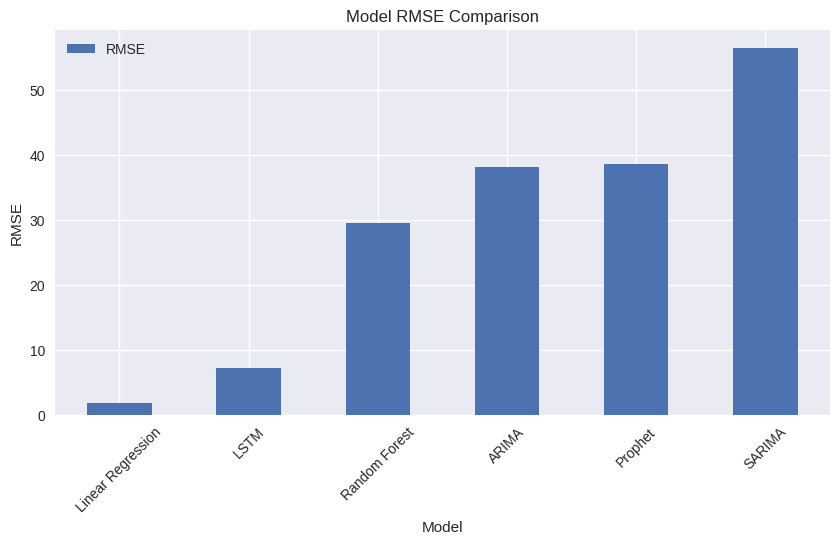

In [51]:
#RMSE
results.plot(x='Model', y='RMSE', kind='bar', figsize=(10,5))
plt.title("Model RMSE Comparison")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.show()



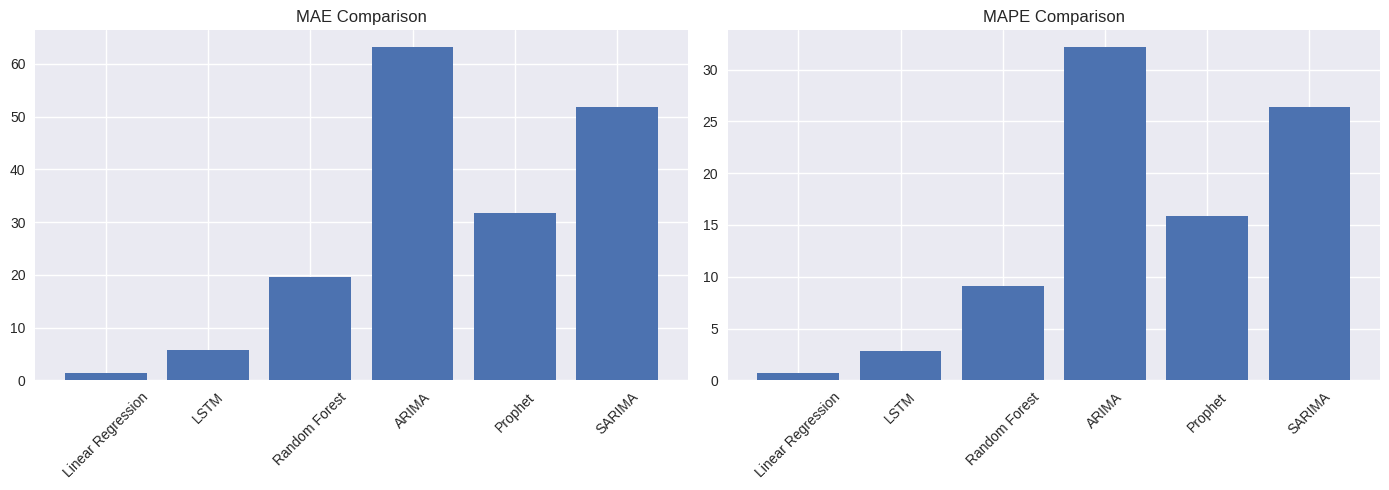

In [52]:

fig, ax = plt.subplots(1, 2, figsize=(14,5))

# MAE
ax[0].bar(results['Model'], results['MAE'])
ax[0].set_title("MAE Comparison")
ax[0].set_xticklabels(results['Model'], rotation=45)

# MAPE
ax[1].bar(results['Model'], results['MAPE (%)'])
ax[1].set_title("MAPE Comparison")
ax[1].set_xticklabels(results['Model'], rotation=45)

plt.tight_layout()
plt.show()


#### **Compare all models based on performance metrics**



*   Linear Regression achieved the lowest error across all metrics, indicating superior short-term predictive performance.
*   LSTM performed second best, significantly outperforming traditional statistical models.
*   Random Forest showed moderate performance, capturing nonlinear patterns but not surpassing simpler linear regression.
*   ARIMA and Prophet performed similarly, suggesting limited deterministic structure in the stock price data.
*   SARIMA performed worst, indicating that adding seasonality did not improve forecasting for this dataset.

These results suggest that short-term stock price movements exhibit strong immediate autocorrelation, which simple lag-based regression models capture effectively.



#### **Discuss advantages and limitations of each approach**



**Linear Regression**

**Advantages:**

*   Simple and interpretable.
*   Extremely strong short-term performance.
*   Low computational cost.
*   No need for stationarity assumptions.

**Limitations:**

*   Assumes linear relationships.
*   May fail under sudden market shocks.
*   Limited ability to model long-term nonlinear dynamics.

**LSTM (Neural Network)**

**Advantages:**

*   Captures nonlinear and long-term dependencies.
*   Handles complex temporal patterns.
*   Performs significantly better than classical models.

**Limitations:**

*   Computationally expensive.
*   Requires scaling and careful tuning.
*   Risk of overfitting.
*   Did not outperform simple linear regression in this case.

**Random Forest**

**Advantages:**

* Handles nonlinear relationships.

* Robust to noise.

* Less sensitive to outliers.

**Limitations:**

* Cannot extrapolate trends effectively.

* Requires manual feature engineering.

* Moderate performance relative to LSTM.

**ARIMA**

**Advantages:**

* Strong theoretical foundation.

* Interpretable structure.

* Suitable for stationary data.

**Limitations:**

* Requires differencing.

* Cannot model nonlinear relationships.

* High forecasting error in volatile financial data.

**SARIMA**

**Advantages:**

* Incorporates seasonality.

* Suitable for cyclical data.

**Limitations:**

* Stock data shows weak deterministic seasonality.

* Highest error among models.

* Sensitive to parameter selection.

**Prophet**

**Advantages:**

* Automatically models trend and seasonality.

* Handles holidays and external events.

* Easy to implement.

**Limitations:**

* Assumes additive structure.

* Less effective for highly volatile financial series.

* Moderate predictive performance.



#### **Suggest improvements for better forecasting**


While lag-based models performed strongly, forecasting stock prices remains challenging due to volatility and stochastic behavior. The following improvements could enhance predictive performance:

1. Use Log Returns Instead of Price Levels

Stock prices behave like a random walk. Modeling log returns may improve statistical properties and reduce non-stationarity issues.

2. Include External Variables

Add:

Trading volume

Volatility index (VIX)

Macroeconomic indicators

Technical indicators (RSI, MACD)

3. Use Walk-Forward Validation

Instead of a single train-test split, apply rolling window validation for more robust evaluation.

4. Hyperparameter Optimization

Use:

Bayesian optimization

Grid search for LSTM architecture tuning

Automated ARIMA selection

5. Ensemble Methods

Combine predictions from:

Linear Regression

LSTM

Random Forest

Ensemble models often improve stability and reduce variance.

6. Volatility Modeling

Use GARCH models to capture volatility clustering, which was observed in residual diagnostics.



#### **Conclusion**

The comparative analysis demonstrates that machine learning models outperform traditional statistical approaches for short-term stock price forecasting. Linear Regression achieved the lowest error metrics, indicating strong short-term linear dependence in stock prices. LSTM also showed strong predictive capability, confirming the presence of temporal structure in the data.

However, the persistence of forecast error across all models highlights the inherent unpredictability of financial markets. The results suggest that while advanced models provide incremental improvements, stock prices largely exhibit stochastic behavior, limiting deterministic forecasting accuracy.